# Cichlid Analysis

Notebook is only used to orchestrate and execute main functions. Key scripts are placed in src/ folder


In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


In [2]:
from src.config import DATA_DIR, IMAGES_DIR, CLIPS_DIR, FPS, SEED, PROJECT_TO_VIDEO
from src.loaders import load_pose, load_pairs, load_circling_csv
from src.video import video_info, batch_render_circling_clips
from src.eda import plot_pose_pair_summary
from src import circling, bower

IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## Load data (0028_vid)

In [3]:
PARQUET_POSE = DATA_DIR / "0028_vid.parquet"
PARQUET_PAIRS = DATA_DIR / "0028_vid_pairs.parquet"
VIDEO_PATH = DATA_DIR / "0028_vid.mp4"

df_pose = load_pose(PARQUET_POSE)
df_pairs = load_pairs(PARQUET_PAIRS)
vinfo = video_info(VIDEO_PATH)

print(f"df_pose : {df_pose.shape}")
print(f"df_pairs : {df_pairs.shape}")
print(f"vinfo : {vinfo}")


df_pose : (1372748, 46)
df_pairs : (636505, 29)
vinfo : {'n_frames': 1080175, 'fps': 29.999994467043397, 'width': 1296, 'height': 972}


## Circling annotations

In [4]:
circling_csv = load_circling_csv(DATA_DIR / "Circling - Sheet1.csv", DATA_DIR, PROJECT_TO_VIDEO, FPS)
circling_csv

,ProjectID,StartFrame,StopFrame,video_stem,video_path,start_s,stop_s,duration_s,start_hms,stop_hms
0,F1_613,265510,266227,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,8850.333333,8874.233333,23.900000,02:27:30,02:27:54
1,F1_613,266809,267100,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,8893.633333,8903.333333,9.700000,02:28:13,02:28:23
2,F1_613,267242,267837,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,8908.066667,8927.900000,19.833333,02:28:28,02:28:47
3,F1_613,269089,271817,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,8969.633333,9060.566667,90.933333,02:29:29,02:31:00
4,F1_613,272241,273018,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,9074.700000,9100.600000,25.900000,02:31:14,02:31:40
5,F1_613,273550,274787,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,9118.333333,9159.566667,41.233333,02:31:58,02:32:39
6,F1_613,275040,275190,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,9168.000000,9173.000000,5.000000,02:32:48,02:32:53
7,F1_613,276439,276530,0031_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0031_vid.mp4,9214.633333,9217.666667,3.033333,02:33:34,02:33:37
8,MC920,334703,334830,0028_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0028_vid.mp4,11156.766667,11161.000000,4.233333,03:05:56,03:06:01
9,MC920,334985,335118,0028_vid,/mnt/c/Users/thaku/OneDrive/Desktop/Rupak/OMSCS/CS8903-Biomedical AI/Cichlid project/cichlid-analysis/ground-truth-annotations/data/0028_vid.mp4,11166.166667,11170.600000,4.433333,03:06:06,03:06:10


## EDA

Sex breakdown (df_pose):
Sex
female    777159
male      595589
Name: count, dtype: int64

Unique TrackUIDs: 13427

Pair sex breakdown (df_pairs):
pair_sex
FM    429596
FF    170234
MM     36675
Name: count, dtype: int64


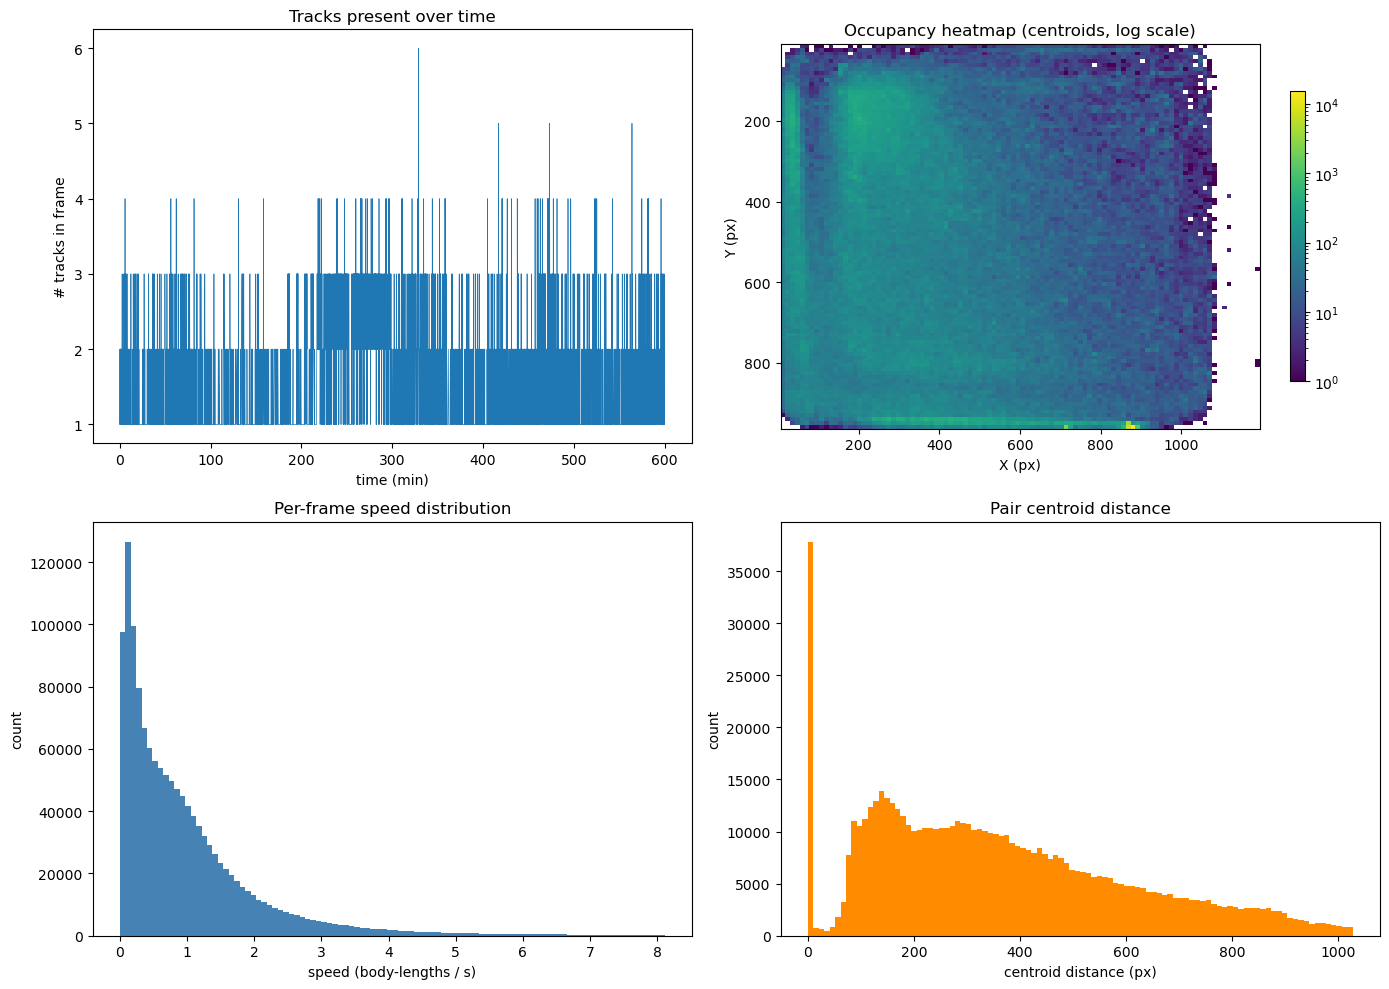

In [5]:
print("Sex breakdown (df_pose):")
print(df_pose["Sex"].value_counts(dropna=False))
print(f"\nUnique TrackUIDs: {df_pose['TrackUID'].nunique()}")
print("\nPair sex breakdown (df_pairs):")
print(df_pairs["pair_sex"].value_counts(dropna=False))

plot_pose_pair_summary(df_pose, df_pairs, fps=FPS, seed=SEED)


## Cut circling clips (with pose overlay)

In [6]:
pose_by_stem = {"0028_vid": df_pose}
p31 = DATA_DIR / "0031_vid.parquet"
if p31.exists():
    pose_by_stem["0031_vid"] = load_pose(p31)

clips_df = batch_render_circling_clips(circling_csv, pose_by_stem, fps=FPS)
clips_df

Rendering 15 clips from 2 video(s)
video_stem
0028_vid    7
0031_vid    8


  0%|          | 0/15 [00:00<?, ?it/s]

,clip,video_stem,start_frame,stop_frame,duration_s,n_frames,size_mb,status
0,0031_vid__f265510-266227.mp4,0031_vid,265510,266227,23.933,718,68.50,ok
1,0031_vid__f266809-267100.mp4,0031_vid,266809,267100,9.733,292,27.93,ok
2,0031_vid__f267242-267837.mp4,0031_vid,267242,267837,19.867,596,56.51,ok
3,0031_vid__f269089-271817.mp4,0031_vid,269089,271817,90.967,2729,256.39,ok
4,0031_vid__f272241-273018.mp4,0031_vid,272241,273018,25.933,778,74.11,ok
5,0031_vid__f273550-274787.mp4,0031_vid,273550,274787,41.267,1238,117.28,ok
6,0031_vid__f275040-275190.mp4,0031_vid,275040,275190,5.033,151,13.94,ok
7,0031_vid__f276439-276530.mp4,0031_vid,276439,276530,3.067,92,8.92,ok
8,0028_vid__f334703-334830.mp4,0028_vid,334703,334830,4.267,128,9.61,ok
9,0028_vid__f334985-335118.mp4,0028_vid,334985,335118,4.467,134,10.15,ok


## Circling detection: vid 28 (MC920)

In [5]:
df_pairs = circling.add_circling_features(df_pose, df_pairs)
df_pairs = circling.add_rule_hit(df_pairs)
events_df = circling.detect_circling_events(df_pairs, video_id=VIDEO_PATH.stem, fps=FPS)
print(f"{len(events_df)} detected events")
events_df.head(20)

158 detected events


,video_id,event_id,start_time,end_time,behavior,fish_ids,confidence,pair_episode_id,TrackUID_1,TrackUID_2,sex_1,sex_2,start_frame,stop_frame,n_hit,duration_s,max_score
0,0028_vid,0028_vid_evt_0000,01:54:23,01:54:25,circling,27015416|27015431,0.3424,27003835,27015416,27015431,female,male,205907,205976,30,2.333,0.4588
1,0028_vid,0028_vid_evt_0001,01:54:32,01:54:46,circling,27015416|27015431,0.3707,27003835,27015416,27015431,female,male,206170,206587,171,13.933,0.6878
2,0028_vid,0028_vid_evt_0002,02:01:15,02:01:17,circling,27015991|27016008,0.1490,27003983,27015991,27016008,female,male,218254,218318,16,2.167,0.2479
3,0028_vid,0028_vid_evt_0003,03:04:48,03:04:51,circling,27019885|27019890,0.5081,27004804,27019885,27019890,female,male,332668,332733,11,2.200,0.7147
4,0028_vid,0028_vid_evt_0004,03:04:52,03:05:05,circling,27019890|27019908,0.3953,27004810,27019890,27019908,male,female,332783,333175,200,13.100,0.6533
5,0028_vid,0028_vid_evt_0005,03:05:55,03:06:01,circling,27019985|27020025,0.4421,27004861,27019985,27020025,female,male,334657,334834,84,5.933,0.6800
6,0028_vid,0028_vid_evt_0006,03:06:05,03:06:11,circling,27019985|27020025,0.5109,27004861,27019985,27020025,female,male,334978,335132,92,5.167,0.7086
7,0028_vid,0028_vid_evt_0007,03:06:20,03:06:23,circling,27019985|27020108,0.4506,27004881,27019985,27020108,female,male,335419,335512,52,3.133,0.6302
8,0028_vid,0028_vid_evt_0008,03:06:30,03:06:34,circling,27019985|27020140,0.3681,27004886,27019985,27020140,female,male,335729,335839,39,3.700,0.7063
9,0028_vid,0028_vid_evt_0009,03:06:45,03:06:47,circling,27019985|27020159,0.5638,27004890,27019985,27020159,female,male,336153,336213,46,2.033,0.7163


In [6]:
labels_0028 = circling_csv[circling_csv["video_stem"] == "0028_vid"].reset_index(drop=True)
matched = []
for _, lab in labels_0028.iterrows():
    hits = events_df[(events_df["stop_frame"] >= lab.StartFrame) & (events_df["start_frame"] <= lab.StopFrame)]
    matched.append((lab.StartFrame, lab.StopFrame, len(hits)))
recall = sum(1 for _, _, n in matched if n > 0)
print(f"recall: {recall}/{len(labels_0028)}")
for s, e, n in matched: print(f"  label f{s}-{e}: {n} overlapping events")


recall: 7/7
  label f334703-334830: 1 overlapping events
  label f334985-335118: 1 overlapping events
  label f335409-335502: 1 overlapping events
  label f336153-336285: 1 overlapping events
  label f436636-436895: 2 overlapping events
  label f437259-437437: 1 overlapping events
  label f713035-713330: 1 overlapping events


#### Plot detected events on a timeline

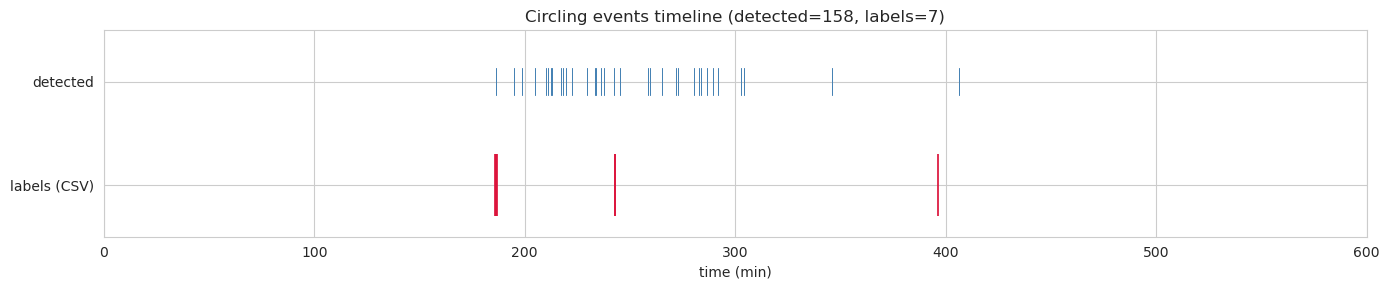

In [17]:
circling.plot_events_timeline(events_df, labels_df=labels_0028, fps=FPS, video_duration_s=vinfo["n_frames"]/FPS, save_path=IMAGES_DIR / "vid_0028_timeline.png")


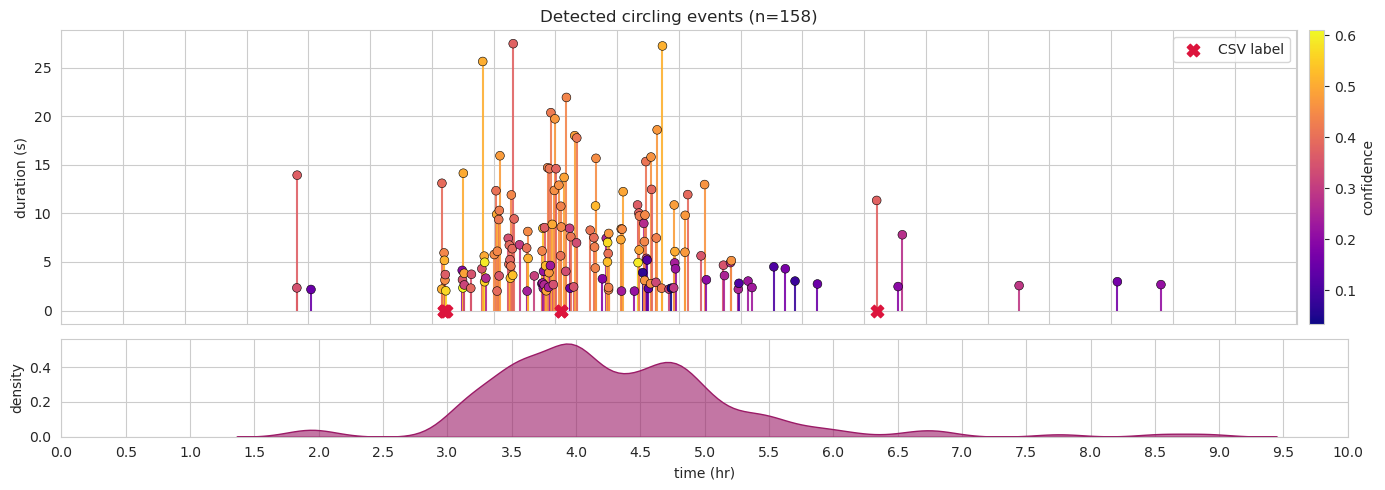

In [18]:
circling.plot_events_rich_timeline(events_df, labels_df=labels_0028, fps=FPS, video_duration_s=vinfo["n_frames"]/FPS, save_path=IMAGES_DIR / "vid_0028_rich_timeline.png")

## Circling detection: vid 31 (F1_613)

In [9]:
PARQUET_POSE_31 = DATA_DIR / "0031_vid.parquet"
PARQUET_PAIRS_31 = DATA_DIR / "0031_vid_pairs.parquet"
VIDEO_PATH_31 = DATA_DIR / "0031_vid.mp4"

df_pose_31 = load_pose(PARQUET_POSE_31)
df_pairs_31 = load_pairs(PARQUET_PAIRS_31)
vinfo_31 = video_info(VIDEO_PATH_31)

print(f"df_pose : {df_pose.shape}")
print(f"df_pairs : {df_pairs.shape}")
print(f"vinfo : {vinfo}")

df_pose : (1372748, 46)
df_pairs : (636505, 44)
vinfo : {'n_frames': 1080175, 'fps': 29.999994467043397, 'width': 1296, 'height': 972}


In [10]:
df_pairs_31 = circling.add_circling_features(df_pose_31, df_pairs_31)
df_pairs_31 = circling.add_rule_hit(df_pairs_31)
events_df_31 = circling.detect_circling_events(df_pairs_31, video_id=VIDEO_PATH_31.stem, fps=FPS)
print(f"{len(events_df_31)} detected events")
events_df_31.head(20)

178 detected events


,video_id,event_id,start_time,end_time,behavior,fish_ids,confidence,pair_episode_id,TrackUID_1,TrackUID_2,sex_1,sex_2,start_frame,stop_frame,n_hit,duration_s,max_score
0,0031_vid,0031_vid_evt_0000,00:54:26,00:54:28,circling,30004551|30004572,0.1941,30000989,30004551,30004572,female,male,97990,98054,17,2.167,0.5816
1,0031_vid,0031_vid_evt_0001,00:54:35,00:54:39,circling,30004551|30004572,0.4782,30000989,30004551,30004572,female,male,98267,98386,50,4.000,0.6260
2,0031_vid,0031_vid_evt_0002,00:54:47,00:54:51,circling,30004551|30004620,0.3793,30000999,30004551,30004620,female,male,98637,98749,49,3.767,0.6019
3,0031_vid,0031_vid_evt_0003,00:54:58,00:55:07,circling,30004551|30004643,0.4432,30001008,30004551,30004643,female,male,98966,99216,95,8.367,0.6234
4,0031_vid,0031_vid_evt_0004,00:57:59,00:58:01,circling,30004924|30004954,0.1847,30001128,30004924,30004954,female,male,104383,104449,13,2.233,0.2914
5,0031_vid,0031_vid_evt_0005,00:59:28,00:59:31,circling,30005128|30005133,0.6594,30001303,30005128,30005133,male,female,107059,107141,10,2.767,0.7143
6,0031_vid,0031_vid_evt_0006,00:59:56,01:00:01,circling,30005224|30005228,0.4328,30001390,30005224,30005228,male,female,107894,108036,52,4.767,0.5212
7,0031_vid,0031_vid_evt_0007,01:04:09,01:04:13,circling,30005655|30005663,0.2480,30001706,30005655,30005663,male,female,115495,115611,35,3.900,0.5766
8,0031_vid,0031_vid_evt_0008,01:06:37,01:06:45,circling,30005776|30005858,0.4958,30001757,30005776,30005858,female,male,119912,120157,98,8.200,0.7388
9,0031_vid,0031_vid_evt_0009,01:07:33,01:07:36,circling,30005888|30005942,0.5920,30001802,30005888,30005942,female,male,121604,121690,47,2.900,0.6698


In [11]:
labels_0031 = circling_csv[circling_csv["video_stem"] == "0031_vid"].reset_index(drop=True)
matched = []
for _, lab in labels_0031.iterrows():
    hits = events_df_31[(events_df_31["stop_frame"] >= lab.StartFrame) & (events_df_31["start_frame"] <= lab.StopFrame)]
    matched.append((lab.StartFrame, lab.StopFrame, len(hits)))
recall = sum(1 for _, _, n in matched if n > 0)
print(f"recall: {recall}/{len(labels_0031)}")
for s, e, n in matched: print(f"  label f{s}-{e}: {n} overlapping events")


recall: 7/8
  label f265510-266227: 3 overlapping events
  label f266809-267100: 1 overlapping events
  label f267242-267837: 1 overlapping events
  label f269089-271817: 6 overlapping events
  label f272241-273018: 2 overlapping events
  label f273550-274787: 5 overlapping events
  label f275040-275190: 1 overlapping events
  label f276439-276530: 0 overlapping events


#### Plot detected events on a timeline

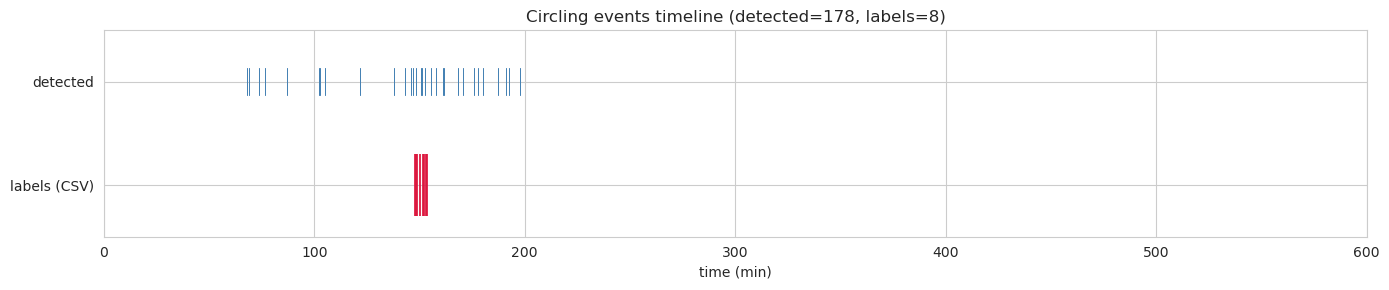

In [15]:
circling.plot_events_timeline(events_df_31, labels_df=labels_0031, fps=FPS, video_duration_s=vinfo_31["n_frames"]/FPS, save_path=IMAGES_DIR / "vid_0031_timeline.png")


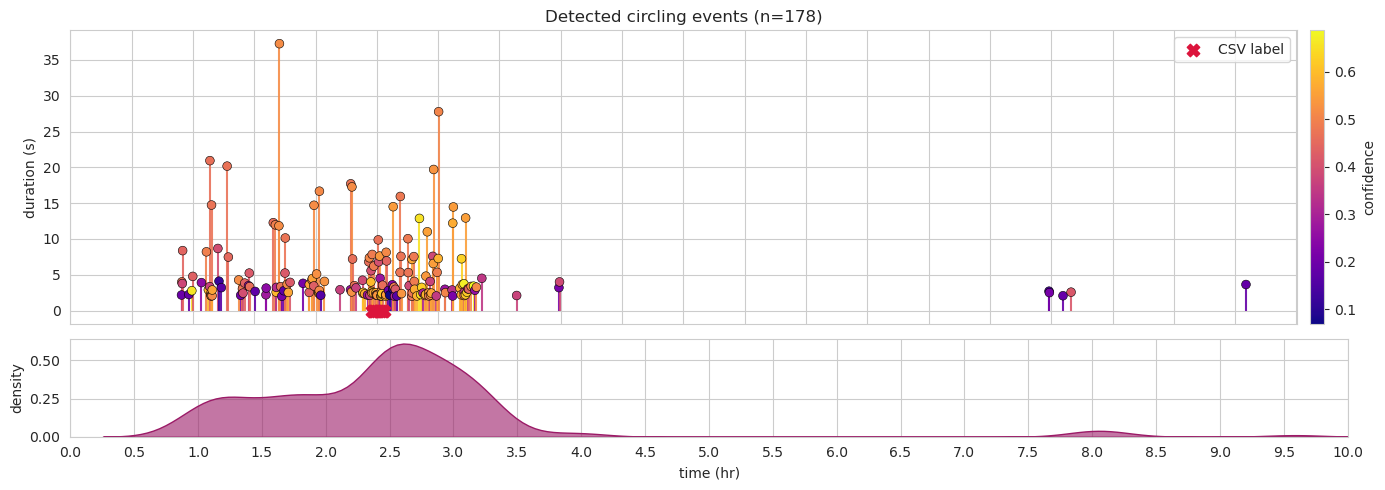

In [16]:
circling.plot_events_rich_timeline(events_df_31, labels_df=labels_0031, fps=FPS, video_duration_s=vinfo_31["n_frames"]/FPS, save_path=IMAGES_DIR / "vid_0031_rich_timeline.png")


## Bower detection

sample [0-3600s]:   0%|          | 0/30 [00:00<?, ?it/s]

sample [32400-36000s]:   0%|          | 0/30 [00:00<?, ?it/s]

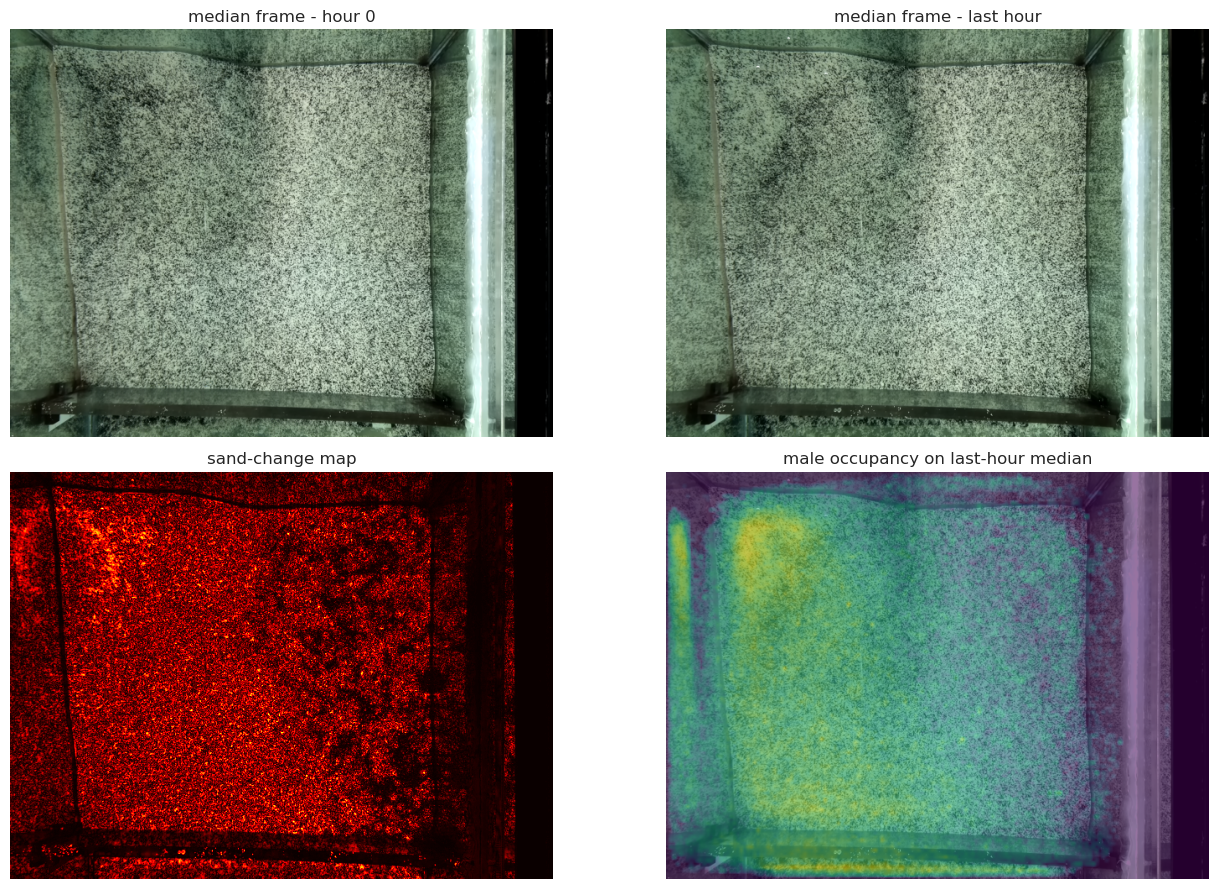

In [14]:
DS = (648, 486)
med0, med1, sand_diff = bower.sand_change_map(VIDEO_PATH, n_video_frames=vinfo["n_frames"], hour_early=0, hour_late=None, n_samples=30, resize=DS, fps=FPS)
male_hm = bower.male_occupancy_heatmap(df_pose, image_size=(vinfo["width"], vinfo["height"]))
bower.plot_bower(med0, med1, sand_diff, male_hm, ds=DS, save_path=IMAGES_DIR / "vid_0028_bower.png")
